In [ ]:
!pip install simpy

Generant gràfic d'una execució...


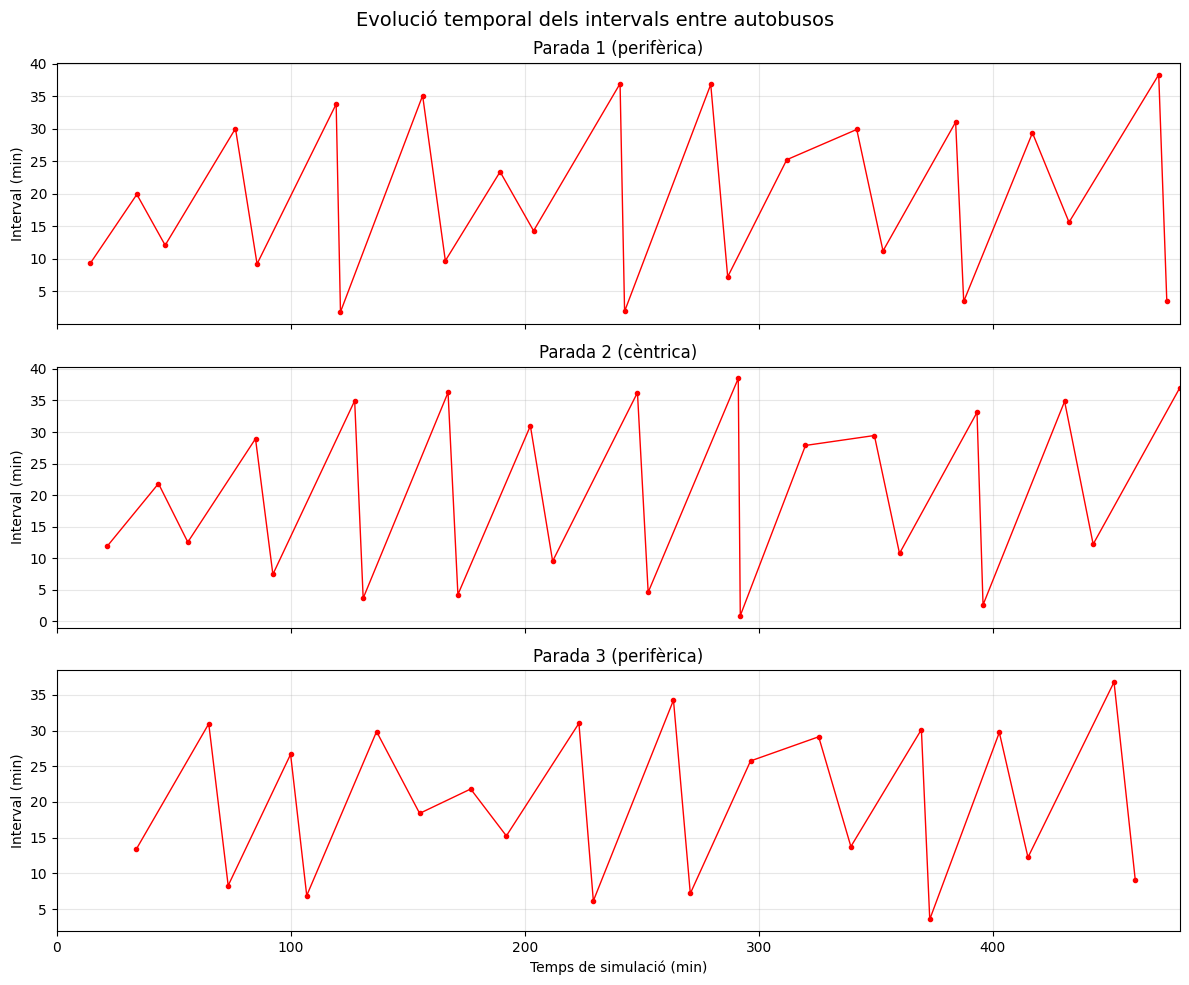


Executant 30 simulacions per verificació creuada...
RESULTATS PYTHON (SimPy) - Verificació Creuada

Parada 1:
  Interval mitjà:  20.27 min  IC95%: [19.79, 20.75]
  Total entrades:  22.8      IC95%: [22.3, 23.3]

Parada 2:
  Interval mitjà:  20.41 min  IC95%: [19.91, 20.91]
  Total entrades:  22.4      IC95%: [21.9, 23.0]

Parada 3:
  Interval mitjà:  20.72 min  IC95%: [20.20, 21.24]
  Total entrades:  21.4      IC95%: [20.8, 21.9]


In [ ]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# MODEL: Bus Bunching - Línia H4 TMB (Prototip SimPy)
# Replica exacta del model GPSS per verificació creuada
# 2 autobusos, 3 parades, sentit únic en bucle
# Unitat de temps: minuts
# ============================================================

# --- Paràmetres (idèntics al GPSS) ---
SIM_TIME = 480              # 8 hores
NUM_BUSES = 2
BUS_SEPARATION = 10         # minuts entre sortides
TRAVEL_TIME_MEAN = 5        # temps trajecte entre parades
TRAVEL_TIME_SPREAD = 1      # ±1 minut (uniforme)
NUM_STOPS = 3

# Taxes d'arribada de passatgers (mitjana exponencial en minuts)
ARRIVAL_RATES = {
    0: 3.0,   # Parada 1: perifèrica (~20 pass/h)
    1: 1.0,   # Parada 2: cèntrica (~60 pass/h)
    2: 2.5,   # Parada 3: perifèrica (~24 pass/h)
}

# FN$TPUJA: distribució discreta temps embarcament
BOARDING_VALUES = [0.3, 0.5, 1.0, 2.0, 3.5]
BOARDING_CUM_PROBS = [0.50, 0.80, 0.93, 0.97, 1.00]


def sample_boarding_time(rng):
    """Mostra un temps d'embarcament segons FN$TPUJA."""
    r = rng.random()
    for val, cum_p in zip(BOARDING_VALUES, BOARDING_CUM_PROBS):
        if r <= cum_p:
            return val
    return BOARDING_VALUES[-1]


def sample_travel_time(rng):
    """Temps de trajecte uniforme: TRAVEL_TIME_MEAN ± TRAVEL_TIME_SPREAD."""
    return TRAVEL_TIME_MEAN + rng.uniform(-TRAVEL_TIME_SPREAD, TRAVEL_TIME_SPREAD)


def sample_exponential(rng, mean):
    """Distribució exponencial amb mitjana donada."""
    return rng.expovariate(1.0 / mean)


def passenger_arrivals(env, stop_id, stop_queues, rng):
    """Procés que genera passatgers a una parada (equivalent als segments 2-4 GPSS)."""
    mean_interarrival = ARRIVAL_RATES[stop_id]
    while True:
        yield env.timeout(sample_exponential(rng, mean_interarrival))
        stop_queues[stop_id] += 1


def bus_process(env, bus_id, stop_queues, results, rng):
    """Procés d'un autobús circulant en bucle (equivalent al segment 5 GPSS)."""
    while True:
        for stop_id in range(NUM_STOPS):
            # Trajecte fins a la parada
            yield env.timeout(sample_travel_time(rng))

            arrival_time = env.now

            # Registrar interval entre autobusos a aquesta parada
            last_time = results["last_bus_time"][stop_id]
            if last_time is not None:
                interval = arrival_time - last_time
                results["intervals"][stop_id].append((arrival_time, interval))
            results["last_bus_time"][stop_id] = arrival_time

            # Embarcar passatgers acumulats
            passengers = stop_queues[stop_id]
            stop_queues[stop_id] = 0

            for _ in range(passengers):
                yield env.timeout(sample_boarding_time(rng))

        # Trajecte de retorn a terminal
        yield env.timeout(sample_travel_time(rng))


def run_simulation(seed=None):
    """Executa una simulació completa i retorna els resultats."""
    rng = random.Random(seed)
    env = simpy.Environment()

    stop_queues = {i: 0 for i in range(NUM_STOPS)}

    results = {
        "intervals": {i: [] for i in range(NUM_STOPS)},
        "last_bus_time": {i: None for i in range(NUM_STOPS)},
    }

    # Llançar generadors de passatgers (un per parada)
    for stop_id in range(NUM_STOPS):
        env.process(passenger_arrivals(env, stop_id, stop_queues,
                                       random.Random(rng.randint(0, 2**32))))

    # Llançar autobusos amb separació inicial
    for bus_id in range(NUM_BUSES):
        bus_rng = random.Random(rng.randint(0, 2**32))
        env.process(bus_delayed_start(env, bus_id, bus_rng,
                                       stop_queues, results))

    env.run(until=SIM_TIME)
    return results


def bus_delayed_start(env, bus_id, rng, stop_queues, results):
    """Inicia un autobús amb el retard corresponent (equivalent a GENERATE 10,,0,2)."""
    yield env.timeout(bus_id * BUS_SEPARATION)
    yield from bus_process(env, bus_id, stop_queues, results, rng)


# ============================================================
# EXECUCIÓ MÚLTIPLE PER VERIFICACIÓ CREUADA (Q8)
# ============================================================

def run_multiple(n_runs=30):
    """Executa n_runs simulacions i recull estadístiques."""
    all_mean_intervals = {i: [] for i in range(NUM_STOPS)}
    all_total_entries = {i: [] for i in range(NUM_STOPS)}

    for run in range(n_runs):
        results = run_simulation(seed=run * 1000 + 42)

        for stop_id in range(NUM_STOPS):
            intervals = [iv for _, iv in results["intervals"][stop_id]]
            if intervals:
                all_mean_intervals[stop_id].append(np.mean(intervals))
                all_total_entries[stop_id].append(len(intervals))

    return all_mean_intervals, all_total_entries


def print_statistics(all_mean_intervals, all_total_entries):
    """Mostra estadístiques amb intervals de confiança."""
    print("=" * 65)
    print("RESULTATS PYTHON (SimPy) - Verificació Creuada")
    print("=" * 65)

    for stop_id in range(NUM_STOPS):
        intervals = all_mean_intervals[stop_id]
        entries = all_total_entries[stop_id]

        mean_iv = np.mean(intervals)
        ci_iv = stats.t.interval(0.95, len(intervals) - 1,
                                  loc=mean_iv, scale=stats.sem(intervals))

        mean_ent = np.mean(entries)
        ci_ent = stats.t.interval(0.95, len(entries) - 1,
                                   loc=mean_ent, scale=stats.sem(entries))

        print(f"\nParada {stop_id + 1}:")
        print(f"  Interval mitjà:  {mean_iv:.2f} min  "
              f"IC95%: [{ci_iv[0]:.2f}, {ci_iv[1]:.2f}]")
        print(f"  Total entrades:  {mean_ent:.1f}      "
              f"IC95%: [{ci_ent[0]:.1f}, {ci_ent[1]:.1f}]")


def plot_single_run(seed=42):
    """Genera el gràfic d'intervals per una execució (comparable al GRAPH de GPSS)."""
    results = run_simulation(seed=seed)

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    stop_names = ["Parada 1 (perifèrica)", "Parada 2 (cèntrica)",
                  "Parada 3 (perifèrica)"]

    for stop_id in range(NUM_STOPS):
        times = [t for t, _ in results["intervals"][stop_id]]
        intervals = [iv for _, iv in results["intervals"][stop_id]]

        axes[stop_id].plot(times, intervals, 'r-o', markersize=3, linewidth=1)
        axes[stop_id].set_ylabel("Interval (min)")
        axes[stop_id].set_title(stop_names[stop_id])
        axes[stop_id].grid(True, alpha=0.3)
        axes[stop_id].set_xlim(0, SIM_TIME)

    axes[2].set_xlabel("Temps de simulació (min)")
    plt.suptitle("Evolució temporal dels intervals entre autobusos", fontsize=14)
    plt.tight_layout()
    plt.savefig("intervals_python.png", dpi=150)
    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    # 1. Gràfic d'una execució individual
    print("Generant gràfic d'una execució...")
    plot_single_run(seed=42)

    # 2. Estadístiques de múltiples execucions
    print("\nExecutant 30 simulacions per verificació creuada...")
    all_intervals, all_entries = run_multiple(n_runs=30)
    print_statistics(all_intervals, all_entries)

In [ ]:
from scipy import stats
import numpy as np

# Dades GPSS extretes de 30 runs
gpss_entries_1 = [30,36,32,17,36,34,28,36,18,19,30,18,18,34,19,18,34,36,34,36,30,26,34,34,17,32,17,20,35,18]
gpss_entries_2 = [30,36,32,16,36,34,28,36,17,18,30,18,18,32,18,17,34,36,34,36,30,26,34,34,17,30,16,20,34,18]
gpss_entries_3 = [28,34,32,16,34,32,28,34,16,18,30,17,17,32,18,16,34,34,32,36,29,25,34,34,16,30,16,18,34,17]

# Intervals mitjans GPSS (estimats com 480/entries)
gpss_intervals_1 = [480/e for e in gpss_entries_1]
gpss_intervals_2 = [480/e for e in gpss_entries_2]
gpss_intervals_3 = [480/e for e in gpss_entries_3]

# Dades Python (de run_multiple)
# all_intervals i all_entries ja calculats anteriorment

print("=" * 60)
print("COMPARISON TESTING: GPSS vs Python")
print("=" * 60)

for stop_id, (gpss_iv, gpss_ent) in enumerate(zip(
    [gpss_intervals_1, gpss_intervals_2, gpss_intervals_3],
    [gpss_entries_1, gpss_entries_2, gpss_entries_3])):

    py_iv = all_intervals[stop_id]
    py_ent = all_entries[stop_id]

    # t-test per total entries
    t_ent, p_ent = stats.ttest_ind(gpss_ent, py_ent)
    # t-test per intervals
    t_iv, p_iv = stats.ttest_ind(gpss_iv, py_iv)

    print(f"\nParada {stop_id + 1}:")
    print(f"  Total entries  - GPSS: {np.mean(gpss_ent):.1f}±{np.std(gpss_ent):.1f}  "
          f"Python: {np.mean(py_ent):.1f}±{np.std(py_ent):.1f}  "
          f"p={p_ent:.4f}")
    print(f"  Interval mitjà - GPSS: {np.mean(gpss_iv):.2f}±{np.std(gpss_iv):.2f}  "
          f"Python: {np.mean(py_iv):.2f}±{np.std(py_iv):.2f}  "
          f"p={p_iv:.4f}")

COMPARISON TESTING: GPSS vs Python

Parada 1:
  Total entries  - GPSS: 27.5±7.6  Python: 22.8±1.4  p=0.0016
  Interval mitjà - GPSS: 19.04±5.91  Python: 20.27±1.27  p=0.2786

Parada 2:
  Total entries  - GPSS: 27.2±7.7  Python: 22.4±1.4  p=0.0019
  Interval mitjà - GPSS: 19.43±6.29  Python: 20.41±1.31  p=0.4153

Parada 3:
  Total entries  - GPSS: 26.4±7.6  Python: 21.4±1.4  p=0.0010
  Interval mitjà - GPSS: 20.10±6.63  Python: 20.72±1.38  p=0.6240


In [7]:
!pip install simpy

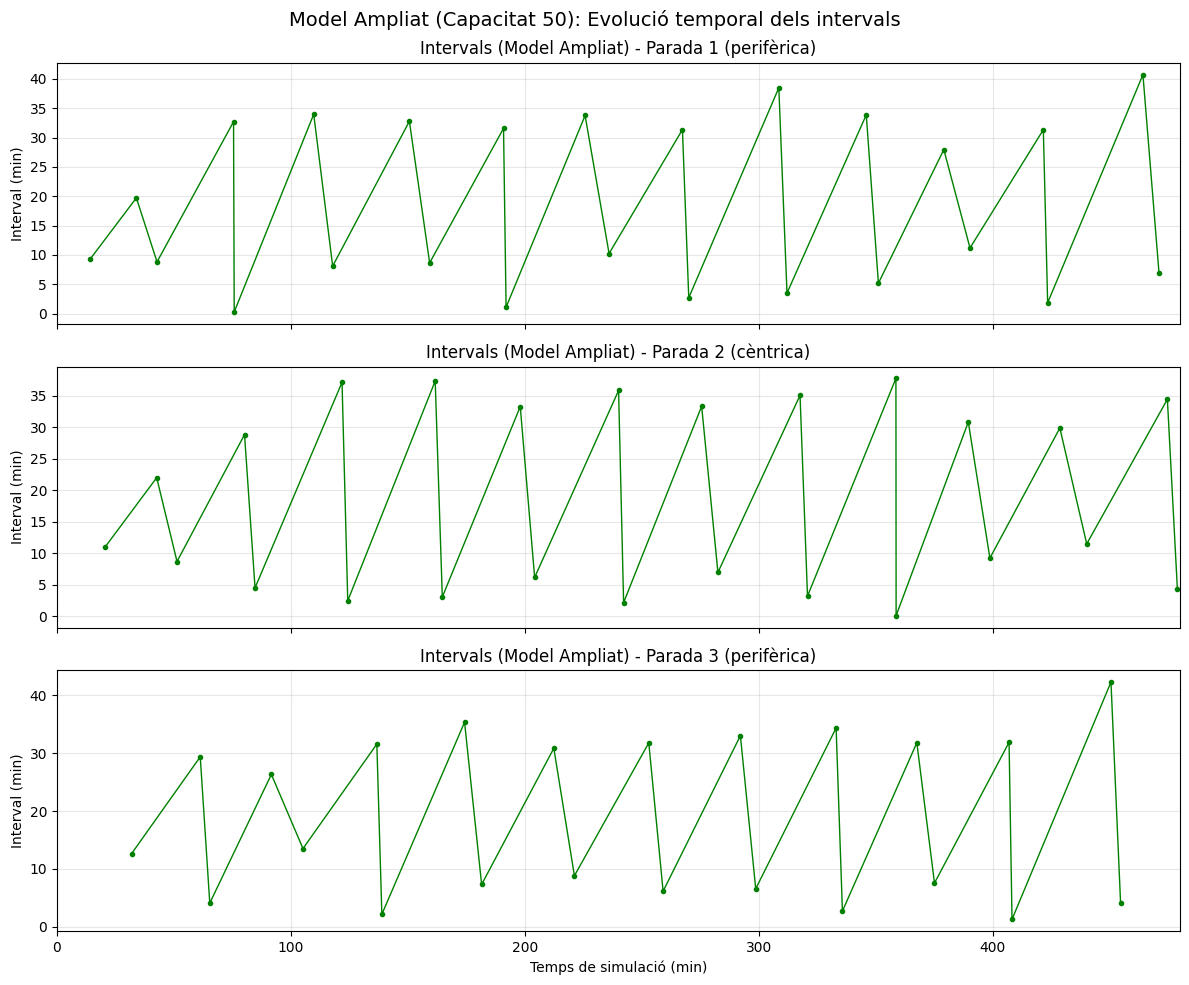

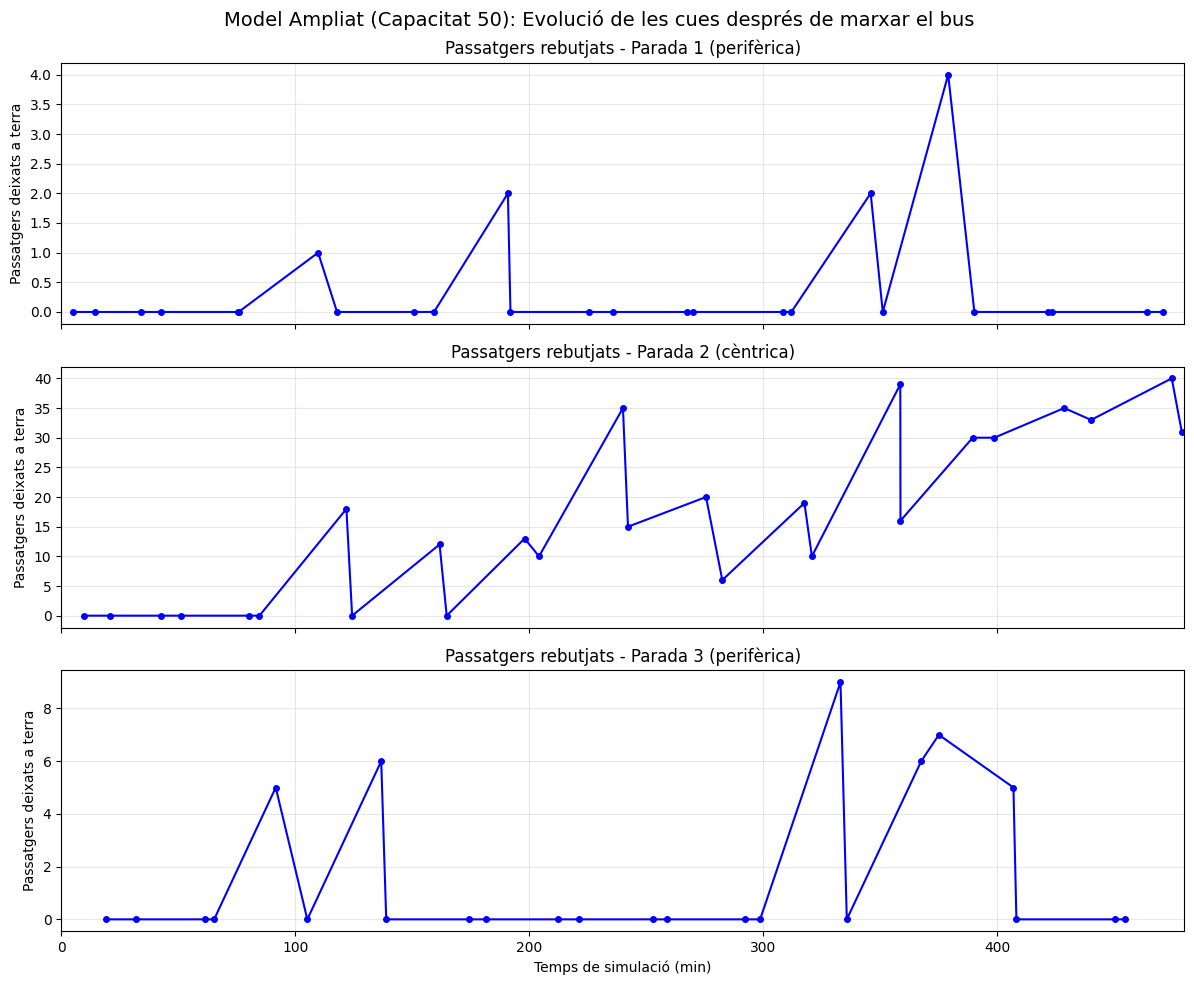

In [14]:
import random
import simpy
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ============================================================
# PART D - MODEL AMPLIAT: Opció B (Capacitat finita)
# ============================================================

# --- Paràmetres (idèntics al GPSS i base del model ampliat) ---
SIM_TIME = 480              # 8 hores
NUM_BUSES = 2
BUS_SEPARATION = 10         # minuts entre sortides
TRAVEL_TIME_MEAN = 5        # temps trajecte entre parades
TRAVEL_TIME_SPREAD = 1      # ±1 minut (uniforme)
NUM_STOPS = 3

# Taxes d'arribada de passatgers (mitjana exponencial en minuts)
ARRIVAL_RATES = {
    0: 3.0,   # Parada 1: perifèrica (~20 pass/h)
    1: 1.0,   # Parada 2: cèntrica (~60 pass/h)
    2: 2.5,   # Parada 3: perifèrica (~24 pass/h)
}

# FN$TPUJA: distribució discreta temps embarcament
BOARDING_VALUES = [0.3, 0.5, 1.0, 2.0, 3.5]
BOARDING_CUM_PROBS = [0.50, 0.80, 0.93, 0.97, 1.00]


def sample_boarding_time(rng):
    """Mostra un temps d'embarcament segons FN$TPUJA."""
    r = rng.random()
    for val, cum_p in zip(BOARDING_VALUES, BOARDING_CUM_PROBS):
        if r <= cum_p:
            return val
    return BOARDING_VALUES[-1]


def sample_travel_time(rng):
    """Temps de trajecte uniforme: TRAVEL_TIME_MEAN ± TRAVEL_TIME_SPREAD."""
    return TRAVEL_TIME_MEAN + rng.uniform(-TRAVEL_TIME_SPREAD, TRAVEL_TIME_SPREAD)


def sample_exponential(rng, mean):
    """Distribució exponencial amb mitjana donada."""
    return rng.expovariate(1.0 / mean)


def passenger_arrivals(env, stop_id, stop_queues, rng):
    """Procés que genera passatgers a una parada (equivalent als segments 2-4 GPSS)."""
    mean_interarrival = ARRIVAL_RATES[stop_id]
    while True:
        yield env.timeout(sample_exponential(rng, mean_interarrival))
        stop_queues[stop_id] += 1

BUS_CAPACITY = 50  # Capacitat màxima de l'autobús

def bus_process_ampliat(env, bus_id, stop_queues, results, rng):
    """Procés d'un autobús amb capacitat finita, baixades i rebutjos."""
    ocupacio = 0  # L'autobús surt buit de la terminal

    while True:
        for stop_id in range(NUM_STOPS):
            # Trajecte fins a la parada
            yield env.timeout(sample_travel_time(rng))
            arrival_time = env.now

            # Registrar interval entre autobusos
            last_time = results["last_bus_time"][stop_id]
            if last_time is not None:
                interval = arrival_time - last_time
                results["intervals"][stop_id].append((arrival_time, interval))
            results["last_bus_time"][stop_id] = arrival_time

            # --- NOVA LÒGICA: CAPACITAT FINITA ---

            # 1. Baixada de passatgers (alliberen espai)
            # Assumim que entre un 10% i un 40% del passatge actual baixa a cada parada
            baixades = int(ocupacio * rng.uniform(0.1, 0.4))
            ocupacio -= baixades

            # 2. Càlcul de quants passatgers poden pujar realment
            espai_lliure = BUS_CAPACITY - ocupacio
            esperant = stop_queues[stop_id]

            pugen = min(esperant, espai_lliure)

            # 3. Actualitzem la cua i l'ocupació
            stop_queues[stop_id] -= pugen  # IMPORTANT: Els que no hi caben ES QUEDEN a la cua
            ocupacio += pugen

            # Registrem l'estat de la cua JUST DESPRÉS que l'autobús marxi (per veure els rebutjats)
            results["cues_post_embarcament"][stop_id].append((arrival_time, stop_queues[stop_id]))

            # 4. Embarcament (només consumim temps pels que pugen)
            for _ in range(pugen):
                yield env.timeout(sample_boarding_time(rng))

        # Trajecte de retorn a terminal
        yield env.timeout(sample_travel_time(rng))


def run_simulation_ampliada(seed=None):
    """Nova funció d'execució que utilitza el bus ampliat i guarda les cues."""
    rng = random.Random(seed)
    env = simpy.Environment()

    stop_queues = {i: 0 for i in range(NUM_STOPS)}

    results = {
        "intervals": {i: [] for i in range(NUM_STOPS)},
        "last_bus_time": {i: None for i in range(NUM_STOPS)},
        "cues_post_embarcament": {i: [] for i in range(NUM_STOPS)} # Nova mètrica
    }

    # Llançar generadors de passatgers
    for stop_id in range(NUM_STOPS):
        env.process(passenger_arrivals(env, stop_id, stop_queues,
                                       random.Random(rng.randint(0, 2**32))))

    # Llançar autobusos amb el nou procés (bus_process_ampliat)
    for bus_id in range(NUM_BUSES):
        bus_rng = random.Random(rng.randint(0, 2**32))

        # En comptes de crear una funció bus_delayed_start_ampliat, ho fem inline:
        def start_bus(env, b_id, b_rng):
            yield env.timeout(b_id * BUS_SEPARATION)
            yield from bus_process_ampliat(env, b_id, stop_queues, results, b_rng)

        env.process(start_bus(env, bus_id, bus_rng))

    env.run(until=SIM_TIME)
    return results

def plot_ampliat_complet(seed=42):
    """Genera els dos gràfics demanats: intervals i cues."""
    results = run_simulation_ampliada(seed=seed)

    stop_names = ["Parada 1 (perifèrica)", "Parada 2 (cèntrica)", "Parada 3 (perifèrica)"]

    # --- 1. GRÀFIC D'INTERVALS (Per comparar amb el de la Part C) ---
    fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    for stop_id in range(NUM_STOPS):
        times = [t for t, _ in results["intervals"][stop_id]]
        intervals = [iv for _, iv in results["intervals"][stop_id]]

        # Fem servir color verd ('g-o') per diferenciar-lo del gràfic base
        axes1[stop_id].plot(times, intervals, 'g-o', markersize=3, linewidth=1)
        axes1[stop_id].set_ylabel("Interval (min)")
        axes1[stop_id].set_title(f"Intervals (Model Ampliat) - {stop_names[stop_id]}")
        axes1[stop_id].grid(True, alpha=0.3)
        axes1[stop_id].set_xlim(0, SIM_TIME)

    axes1[2].set_xlabel("Temps de simulació (min)")
    fig1.suptitle("Model Ampliat (Capacitat 50): Evolució temporal dels intervals", fontsize=14)
    fig1.tight_layout()
    plt.show()

    # --- 2. GRÀFIC DE CUES (Passatgers rebutjats) ---
    fig2, axes2 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    for stop_id in range(NUM_STOPS):
        times = [t for t, _ in results["cues_post_embarcament"][stop_id]]
        cues = [q for _, q in results["cues_post_embarcament"][stop_id]]

        axes2[stop_id].plot(times, cues, 'b-o', markersize=4, linewidth=1.5)
        axes2[stop_id].set_ylabel("Passatgers deixats a terra")
        axes2[stop_id].set_title(f"Passatgers rebutjats - {stop_names[stop_id]}")
        axes2[stop_id].grid(True, alpha=0.3)
        axes2[stop_id].set_xlim(0, SIM_TIME)

    axes2[2].set_xlabel("Temps de simulació (min)")
    fig2.suptitle("Model Ampliat (Capacitat 50): Evolució de les cues després de marxar el bus", fontsize=14)
    fig2.tight_layout()
    plt.show()

# Executar per veure els dos resultats
plot_ampliat_complet(seed=42)
